In [103]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm/examples/logs/dllm'
PDF_PATH = '/root/workspace/vllm/examples/results/pdf'
CSV_PATH = '/root/workspace/vllm/examples/results/csv'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

In [104]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, scheduling_policy, wt_weight):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
    for store_cache_layer in store_cache_layers:
        filename = f'{DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_recompute_{store_cache_layer}_{scheduling_policy}_wt{wt_weight}.log'
        with open(filename, 'r') as f:
            lines = f.readlines()
            output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
            for line in lines:
                if 'Output token throughput' in line:
                    output_tokens_tgt.append(float(line.split()[-1]))
                if 'Request throughput' in line:
                    reqs_tgt.append(float(line.split()[-1]))
                if 'Mean TPOT' in line:
                    mean_tpot_.append(float(line.split()[-1]))
                if 'P99 TPOT' in line:
                    p99_tpot_.append(float(line.split()[-1]))
                if 'Mean TTFT' in line:
                    mean_ttft_.append(float(line.split()[-1]))
                if 'P99 TTFT' in line:
                    p99_ttft_.append(float(line.split()[-1]))    
                if 'Mean ITL' in line:
                    mean_itl_.append(float(line.split()[-1]))
                if 'P99 ITL' in line:
                    p99_itl_.append(float(line.split()[-1]))    

        output_tokens.append(np.mean(output_tokens_tgt))
        reqs.append(np.mean(reqs_tgt))
        mean_tpot.append(np.mean(mean_tpot_))
        p99_tpot.append(np.mean(p99_tpot_))
        mean_ttft.append(np.mean(mean_ttft_))
        p99_ttft.append(np.mean(p99_ttft_))
        mean_itl.append(np.mean(mean_itl_))
        p99_itl.append(np.mean(p99_itl_))

    # return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 
    return output_tokens, reqs, p99_tpot, p99_ttft, p99_itl 

In [117]:
def plot_fig(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers):
    
    scheduling_policy = 'fcfs'
    wt_weight = 1.0
    baseline_output_tokens, baseline_reqs, baseline_p99_tpot, baseline_p99_ttft, baseline_p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, scheduling_policy, wt_weight)
    print('baseline_output_tokens:', baseline_output_tokens)
    print('baseline_reqs:', baseline_reqs)
    scheduling_policy = 'dllm' 
    wt_weights = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    for wt_weight in wt_weights:
        output_tokens, reqs, p99_tpot, p99_ttft, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, scheduling_policy, wt_weight)
        # plot
        output_tokens_impv = [(output_tokens[i]-baseline_output_tokens[i])/baseline_output_tokens[i] *100 for i in range(len(output_tokens))]
        reqs_impv = [(reqs[i]-baseline_reqs[i])/baseline_reqs[i] *100 for i in range(len(reqs))]
        p99_tpot_impv = [(p99_tpot[i]-baseline_p99_tpot[i])/baseline_p99_tpot[i] *100 for i in range(len(p99_tpot))]
        p99_ttft_impv = [(p99_ttft[i]-baseline_p99_ttft[i])/baseline_p99_ttft[i] *100 for i in range(len(p99_ttft))]
        p99_itl_impv = [(p99_itl[i]-baseline_p99_itl[i])/baseline_p99_itl[i] *100 for i in range(len(p99_itl))]

        print('output_tokens_impv:', output_tokens_impv)
        print('reqs_impv:', reqs_impv)
        print('p99_tpot_impv:', p99_tpot_impv)
        print('p99_ttft_impv:', p99_ttft_impv)
        print('p99_itl_impv:', p99_itl_impv)

        # save these results to a csv file
        df = pd.DataFrame({'store_cache_layers': store_cache_layers, 'output_tokens_impv': output_tokens_impv, 'reqs_impv': reqs_impv, 'p99_tpot_impv': p99_tpot_impv, 'p99_ttft_impv': p99_ttft_impv, 'p99_itl_impv': p99_itl_impv})
        df.to_csv(f'{CSV_PATH}/{model_name}_{gpu_utilization}_{req_rate}_{total_reqs}_scheduling.csv', index=False)

        fig, ax = plt.subplots(1, 1, figsize=(3, 2.3), dpi=120)
        ax.plot(store_cache_layers, output_tokens_impv, label='Token Tgt', marker=markers[0], markersize=3, linestyle=linestyles[0%len(linestyles)], linewidth=1.5, color=plt.cm.Dark2(0))
        ax.plot(store_cache_layers, reqs_impv, label='Req Tgt', marker=markers[1], markersize=3, linestyle=linestyles[1%len(linestyles)], linewidth=1.5, color=plt.cm.Dark2(1))
        ax.plot(store_cache_layers, p99_tpot_impv, label='TPOT', marker=markers[2], markersize=3, linestyle=linestyles[2%len(linestyles)], linewidth=1.5, color=plt.cm.Dark2(2))
        ax.plot(store_cache_layers, p99_ttft_impv, label='TTFT', marker=markers[3], markersize=3, linestyle=linestyles[3%len(linestyles)], linewidth=1.5, color=plt.cm.Dark2(3))
        ax.plot(store_cache_layers, p99_itl_impv, label='ITL', marker=markers[4], markersize=3, linestyle=linestyles[4%len(linestyles)], linewidth=1.5, color=plt.cm.Dark2(4))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlabel('Store Cache Layers')
        ax.set_ylabel('Improvement (%)')
        ax.title.set_text(f'{wt_weight}')
        # set xticks to be 1/16, 1/8, 1/4, 1/2, 3/4, 1
        # ax.set_xticklabels(['1/16', '1/8', '1/4', '1/2', '3/4', '1'])
        xticks = ax.get_xticks()
        print(xticks)
        # new_ticks = np.array(ax.get_xticks()) - 2
        # ax.set_xticks(new_ticks)
        
        ax.legend(loc='best', ncol=2, frameon=False, handlelength=1.5, columnspacing=0.5, handletextpad=0.2, borderpad=0.1, borderaxespad=0.1)
        ax.grid(True, axis='y', linestyle='-.', linewidth=0.5, alpha=0.5)
        plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.1)
        # plt.savefig(f'{PDF_PATH}/{model_name}_{gpu_utilization}_{req_rate}_{total_reqs}_scheduling.pdf')
        plt.show()
        plt.close()

baseline_output_tokens: [746.9, 781.79, 571.32, 328.88, 276.17, 288.74]
baseline_reqs: [3.11, 3.24, 2.33, 1.61, 1.2, 1.14]
output_tokens_impv: [8.32909358682555, -3.4791951802913736, -2.646502835538753, -4.679518365361222, -4.334286852301129, -5.149961903442545]
reqs_impv: [8.038585209003216, -3.703703703703707, -3.0042918454935745, -4.968944099378886, -3.3333333333333366, -5.263157894736828]
p99_tpot_impv: [0.3193693722237481, 30.117319333583325, 14.041272570937224, -46.94560204478524, -13.263893395634586, -62.71205336405359]
p99_ttft_impv: [1.7388157894736835, 27.89730682014214, 0.816805592704134, 13.19403155535034, 2.551583140220994, 12.001363203415162]
p99_itl_impv: [19.341415801911026, 14.69113022687699, 17.659317498283087, -11.908157444381064, -3.8353510895883764, -3.5183085439871977]
[0.   0.25 0.5  0.75 1.   1.25]


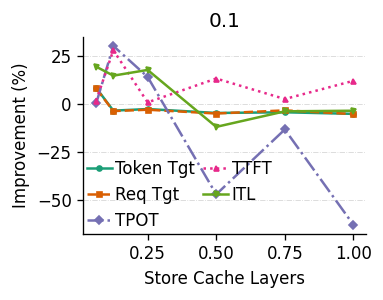

output_tokens_impv: [1.4981925291203715, -5.0614615177988895, -5.744591472379761, -1.3257115057163749, 2.165332947097788, -2.123017247350556]
reqs_impv: [1.6077170418006517, -4.938271604938276, -6.0085836909871295, -1.8633540372670823, 2.500000000000002, -1.7543859649122628]
p99_tpot_impv: [2.198832780984852, 37.74269337027143, 18.367522417393438, -54.09901650275045, -20.34849763125446, -67.55978371950427]
p99_ttft_impv: [3.7030701754385893, 31.622852924009802, 7.578477419002898, 7.14193671272698, -2.5409298156884286, 0.35944658850238465]
p99_itl_impv: [2.4041919243809757, 9.431118272304364, 9.934402159755617, -0.021391899600692106, -5.6690879741727205, -4.168612018942173]
[0.   0.25 0.5  0.75 1.   1.25]


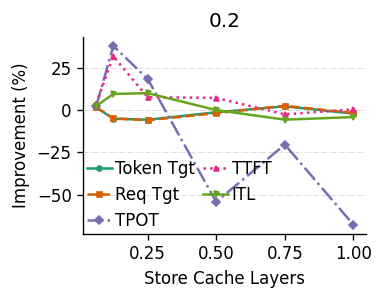

output_tokens_impv: [7.61815504083545, -13.425600225124384, -3.388643842330045, 4.0896375577718285, -3.8671832566897226, -5.974232873865761]
reqs_impv: [7.717041800643094, -13.271604938271608, -3.0042918454935745, 3.1055900621117902, -3.3333333333333366, -6.140350877192969]
p99_tpot_impv: [18.583622180963317, 41.142887754555396, 7.706669942267536, -57.33511140745681, -25.068682804421655, -68.86973002099631]
p99_ttft_impv: [21.976973684210517, 39.94971348484836, 2.9444060414975675, 2.591991356221858, 3.973580517131517, 1.749890781589969]
p99_itl_impv: [-17.224904962498716, 33.99776501468333, 8.416416037132645, -10.855200608480702, -4.726392251815977, -2.694590809044234]
[0.   0.25 0.5  0.75 1.   1.25]


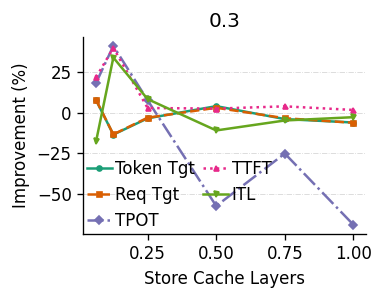

output_tokens_impv: [-5.166688981121975, -4.676447639391645, -1.536791990478206, -2.289588907808311, -0.564869464460297, -5.246934958786463]
reqs_impv: [-5.144694533762048, -4.62962962962964, -1.716738197424894, -1.2422360248447215, 0.0, -5.263157894736828]
p99_tpot_impv: [38.665238798309375, 38.93731489488707, 6.878761822871883, -51.820859032060895, -31.324766911112555, -68.01687136513128]
p99_ttft_impv: [42.68793859649122, 35.82400255991077, 0.7494942968729097, 7.046174410614775, 0.36082243474898423, 2.3568647611379734]
p99_itl_impv: [24.863865200863046, 15.22128953455131, 15.22248798162314, -8.787316980414534, -0.6682808716706999, -6.209564463416262]
[0.   0.25 0.5  0.75 1.   1.25]


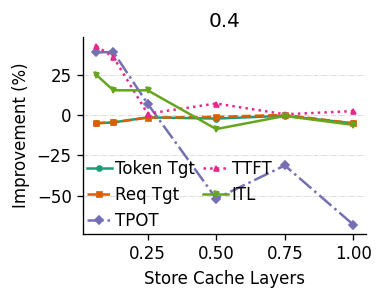

output_tokens_impv: [3.7407952871870473, -9.207076069021095, -5.800602114401753, -2.8946728289953727, 1.8249628851794053, -4.02784512017732]
reqs_impv: [3.536977491961425, -9.567901234567902, -6.0085836909871295, -3.105590062111804, 3.3333333333333366, -3.508771929824545]
p99_tpot_impv: [30.469992586068155, 37.546778501404305, 5.687262007124426, -17.39512140912374, -48.36891859735652, -62.00598301715008]
p99_ttft_impv: [35.22072368421052, 33.039027019393295, 3.904569770563931, 10.380843932994178, -3.4954667413399414, 12.055490924772002]
p99_itl_impv: [-16.449193465529646, 16.14127186257438, 13.81817320671609, 1.9324015972618358, -11.060532687651328, -1.9709197625558676]
[0.   0.25 0.5  0.75 1.   1.25]


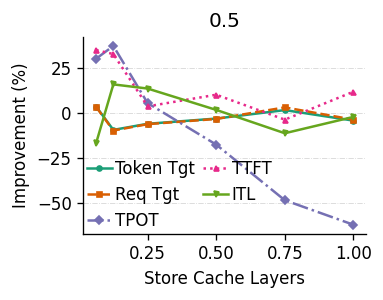

output_tokens_impv: [2.3564064801178235, -6.573376482175519, 1.8448505215990971, -5.424470931646794, -2.299308397001855, -11.387407356098912]
reqs_impv: [2.2508038585209094, -6.481481481481493, 1.2875536480686611, -5.590062111801246, -2.500000000000002, -11.403508771929815]
p99_tpot_impv: [43.8689318235104, 45.73540778608544, 6.146665028866228, -53.274434627993564, -11.384039630518961, -58.98102900462663]
p99_ttft_impv: [48.878508771929816, 43.183835379146565, -1.818228367208333, 10.779296257906756, 9.404251995652945, 12.025983814445249]
p99_itl_impv: [-13.880612349738012, 17.391304347826075, 5.842233641982622, -5.255276668568172, -5.426957223567394, 0.12339091576068983]
[0.   0.25 0.5  0.75 1.   1.25]


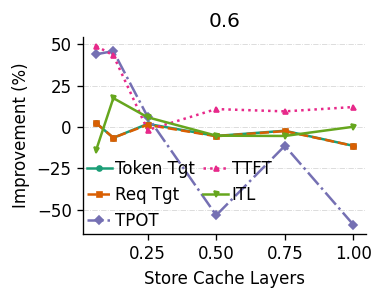

output_tokens_impv: [1.0643995180077714, -7.655508512516137, 0.4410838059231222, -2.909875942593041, -4.38498026577833, -8.145736648888265]
reqs_impv: [0.9646302250803939, -7.716049382716049, 0.429184549356214, -2.484472049689443, -4.1666666666666705, -7.894736842105251]
p99_tpot_impv: [49.947088605990714, 55.758443089026464, 8.000245670065102, -44.87192309829416, 74.3915893309105, -62.494658020401715]
p99_ttft_impv: [54.905263157894744, 52.719324197860374, 0.5814733634716073, 9.665891376471315, 12.266767437496842, 16.889985507117853]
p99_itl_impv: [-4.870029795540938, 11.294472309571448, 15.054349113126673, -2.6430880395512464, -6.72477804681194, 7.363436270259449]
[0.   0.25 0.5  0.75 1.   1.25]


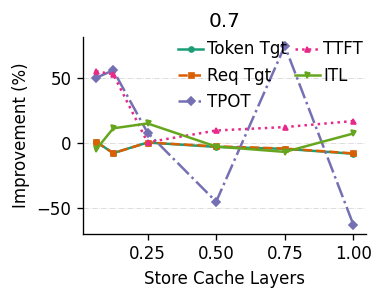

output_tokens_impv: [4.4423617619494, -6.976297982834261, 0.6091157319890611, -6.72585745560691, -6.336676684650758, -7.3734155295421555]
reqs_impv: [4.180064308681683, -7.098765432098777, 0.429184549356214, -8.074534161490691, -5.833333333333339, -7.01754385964911]
p99_tpot_impv: [38.77803194961063, 57.014288010163085, 4.785652868198, -0.5489803856198316, -12.169295000757133, -65.48059235585947]
p99_ttft_impv: [44.66644736842105, 51.79761331225103, -0.8845028478004493, 15.571949647587951, 14.945742813411092, 10.25658286701081]
p99_itl_impv: [-15.2650775711497, 53.3641726656098, 10.860350013024846, -6.750332762882685, 0.5294592413236437, 0.7370106049489693]
[0.   0.25 0.5  0.75 1.   1.25]


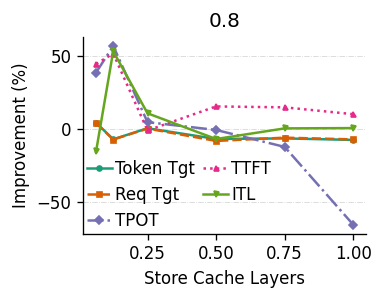

output_tokens_impv: [-3.197215155978042, -7.383056831118321, 1.8273471959672234, -7.595475553393341, -9.171886881268787, -1.7766849068365989]
reqs_impv: [-3.2154340836012896, -7.407407407407414, 1.2875536480686611, -7.453416149068329, -9.166666666666657, -1.7543859649122628]
p99_tpot_impv: [32.53131910956777, 49.824365381230436, 3.0549072595504243, -45.67761293548925, -14.224371038570533, -64.61472714097253]
p99_ttft_impv: [36.85592105263158, 47.430838165194714, -1.7166052927108737, 14.684053904896649, 8.887134765269694, 9.283887335152311]
p99_itl_impv: [1.5873831295592333, 1.2916136074222226, 4.2508347739598, -8.437915953603346, 0.6908797417271949, 4.5721336623757685]
[0.   0.25 0.5  0.75 1.   1.25]


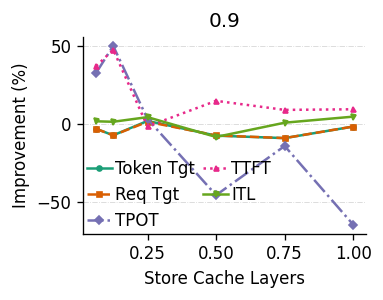

In [118]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.4
req_rate = 300
total_reqs = 300
store_cache_layers = [0.0625, 0.125, 0.25, 0.5, 0.75, 1.0]
plot_fig(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers)